In [2]:
import numpy as np
import pandas as py
import matplotlib.pyplot as plt

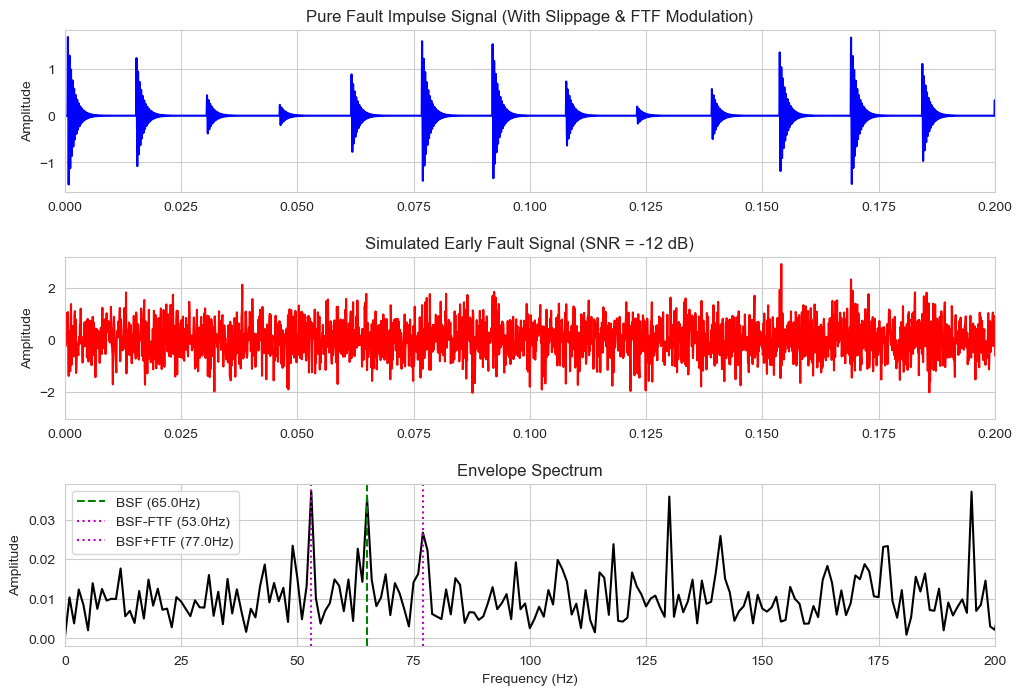

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert

def simulate_rolling_element_fault(fs=12000, duration=1.0, snr_db=-10):
    """
    模拟滚动体初期故障振动信号
    
    参数:
    fs: 采样频率 (Hz)
    duration: 信号时长 (s)
    snr_db: 信噪比 (dB)，初期故障通常在 -10 到 -15 dB
    """
    t = np.arange(0, duration, 1/fs)
    N = len(t)
    
    # --- 1. 定义轴承特征频率先验参数 ---
    bsf = 65.0      # 滚动体自转频率 (Ball Spin Frequency), 假设为 65 Hz
    ftf = 12.0      # 保持架公转频率 (Fundamental Train Frequency), 假设为 12 Hz
    fn = 3000.0     # 轴承系统的高频固有共振频率 (Hz)
    beta = 800.0    # 结构阻尼系数 (决定冲击衰减快慢)
    
    # 滚动体缺陷通常每次自转撞击内外圈各一次，冲击频率为 2*BSF
    # 这里我们简化为单侧撞击或以 BSF 为主要特征周期来模拟
    fault_freq = bsf 
    T = 1.0 / fault_freq
    
    # --- 2. 生成带随机打滑的冲击序列 ---
    num_impacts = int(np.floor(duration / T))
    signal_clean = np.zeros(N)
    
    # 模拟打滑带来的周期误差 (标准差为周期的 1.5%)
    slip_std = 0.015 * T 
    
    for i in range(num_impacts):
        # 加入随机打滑时间偏移
        tau_i = np.random.normal(0, slip_std)
        t_impact = i * T + tau_i
        
        if t_impact < 0 or t_impact >= duration:
            continue
            
        # 截取从当前冲击点开始的时间向量
        idx_start = int(t_impact * fs)
        t_decay = t[idx_start:] - t[idx_start]
        
        # --- 3. 保持架转频幅值调制 (进出承载区) ---
        # 冲击幅值受保持架频率 ftf 调制
        A_i = 1.0 + 0.8 * np.cos(2 * np.pi * ftf * t_impact)
        
        # --- 4. 生成单次指数衰减振铃响应 ---
        response = A_i * np.exp(-beta * t_decay) * np.sin(2 * np.pi * fn * t_decay)
        
        # 叠加到总信号中
        signal_clean[idx_start:] += response

    # --- 5. 加入极强的背景噪声模拟初期故障 ---
    # 计算纯净信号功率
    power_signal = np.sum(signal_clean**2) / N
    # 根据目标 SNR 计算噪声功率
    power_noise = power_signal / (10 ** (snr_db / 10))
    # 生成高斯白噪声
    noise = np.random.normal(0, np.sqrt(power_noise), N)
    
    signal_noisy = signal_clean + noise
    return t, signal_noisy, signal_clean

# ================= 运行仿真与可视化 =================
fs = 12000
t, sig_noisy, sig_clean = simulate_rolling_element_fault(fs=fs, duration=1.0, snr_db=-12)

# 计算包络谱 (Envelope Spectrum) 验证理论特征
analytic_signal = hilbert(sig_noisy)
amplitude_envelope = np.abs(analytic_signal)
# 去直流分量
amplitude_envelope -= np.mean(amplitude_envelope)
# FFT
N = len(amplitude_envelope)
frequencies = np.fft.fftfreq(N, 1/fs)[:N//2]
envelope_spectrum = np.abs(np.fft.fft(amplitude_envelope))[:N//2] / N * 2

# 绘图
plt.figure(figsize=(12, 8))
plt.subplots_adjust(hspace=0.4)

plt.subplot(3, 1, 1)
plt.plot(t, sig_clean, color='b')
plt.title('Pure Fault Impulse Signal (With Slippage & FTF Modulation)')
plt.ylabel('Amplitude')
plt.xlim(0, 0.2) # 只看前 0.2 秒细节

plt.subplot(3, 1, 2)
plt.plot(t, sig_noisy, color='r')
plt.title('Simulated Early Fault Signal (SNR = -12 dB)')
plt.ylabel('Amplitude')
plt.xlim(0, 0.2)

plt.subplot(3, 1, 3)
plt.plot(frequencies, envelope_spectrum, color='k')
plt.title('Envelope Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.xlim(0, 200)

# 标记理论频率
bsf, ftf = 65.0, 12.0
plt.axvline(x=bsf, color='g', linestyle='--', label=f'BSF ({bsf}Hz)')
plt.axvline(x=bsf-ftf, color='m', linestyle=':', label=f'BSF-FTF ({bsf-ftf}Hz)')
plt.axvline(x=bsf+ftf, color='m', linestyle=':', label=f'BSF+FTF ({bsf+ftf}Hz)')
plt.legend()
plt.grid(True)
plt.show()